# Data cleaning

In [1]:
# import libraries
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Matplotlib darkmode
plt.style.use('dark_background')


## Read the data from json

In [2]:
with open("../data/raw/rentals_raw.json") as f:
    data = json.load(f)

In [3]:
df = pd.DataFrame(data['properties'])

In [4]:
df

,listing_number,price,title,location,address,bedrooms,bathrooms,parking,floor_size
0,116665802,R 61 279,Commercial Property,Erasmusrand,41 Buffelsdrift Street,None,None,None,422 m²
1,116659879,R 66 865,Commercial Property,Menlyn,221 Garsfontein Road 311m2 Summit Place Ground...,None,None,None,311 m²
2,116696241,R 5 500,8 Bedroom Apartment,Hatfield,1228 Prospect Street,8,8,8,212 m²
3,116665983,R 122 285,Commercial Property,Menlyn,169 Corobay Avenue.s3,None,None,None,661 m²
4,116691726,R 21 000,3 Bedroom Townhouse,Olympus AH,2206 Leander Road,3,2,2,202 m²
...,...,...,...,...,...,...,...,...,...
7537,116509626,R 7 250,2 Bedroom Apartment,Roodeplaat,None,2,1,1,None
7538,116560786,R 7 550,2 Bedroom Apartment,Silverton,None,2,1,2,None
7539,116564366,R 8 450,2 Bedroom Apartment,Roodeplaat,None,2,2,2,None
7540,116564237,R 8 450,2 Bedroom Apartment,Silverton,None,2,2,2,None


In [5]:
def categorise_listing(text):
    if text in ['Commercial Property', 'Industrial Property']:
        return text
    if 'Apartment' in text:
        return 'Apartment'
    if 'Townhouse' in text:
        return 'Townhouse'
    if 'House' in text:
        return 'House'
    return text

df.loc[:,'type'] = df['title'].apply(lambda x: categorise_listing(x))

In [6]:
df['type'].value_counts()

type
Apartment              3220
Commercial Property    1959
House                  1323
Townhouse               703
Industrial Property     326
Farm                      6
Vacant Land               5
Name: count, dtype: int64

In [7]:
res_df = df[(df['type'] == 'Apartment') | (df['type'] == 'House') | (df['type'] == 'Townhouse')].copy()

In [8]:
res_df.shape

(5246, 10)

In [9]:
res_df.isnull().sum()

listing_number       0
price                0
title                0
location             0
address           3354
bedrooms           143
bathrooms           95
parking            599
floor_size        2346
type                 0
dtype: int64

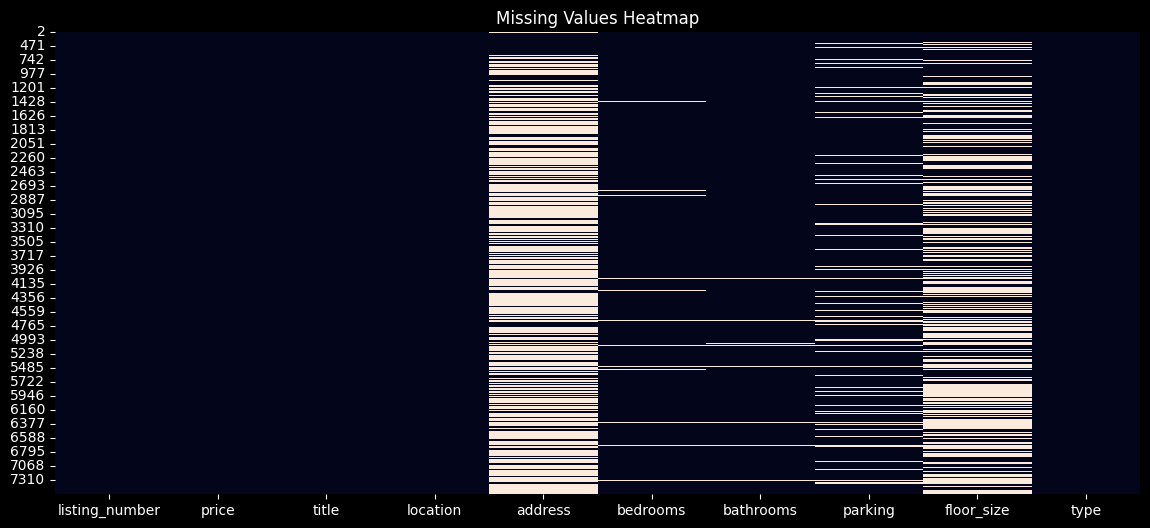

In [10]:
plt.figure(figsize=(14, 6))
sns.heatmap(res_df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

We will be dropping the `address` column as there is too many missing values. `location` will be used for modelling instead.

In [11]:
res_df = res_df.drop(columns=["address","title"])

In [12]:
res_df['price'] = res_df['price'].str.replace(r'[^\d]', '', regex=True)
res_df['floor_size'] = res_df['floor_size'].str.replace(r'[^\d]', '', regex=True)

In [13]:
numerical_cols = ['price', 'bedrooms', 'bathrooms', 'parking', 'floor_size']

for col in numerical_cols:
    res_df[col] = res_df[col].apply(pd.to_numeric, errors='coerce')

In [14]:
res_df[res_df['price'].isnull()]

,listing_number,price,location,bedrooms,bathrooms,parking,floor_size,type
3120,116564621,NaN,Lynnwood Ridge,4.0,4.0,9.0,750.0,House
4078,116573829,NaN,Erasmuskloof,3.0,2.0,4.0,NaN,Townhouse
4612,116645947,NaN,Montana Park,2.0,1.0,1.0,NaN,Apartment
5714,116394589,NaN,Waterkloof Ridge,5.0,3.0,2.0,NaN,House
5848,116538701,NaN,Mooikloof Ridge,2.0,1.0,2.0,NaN,Apartment
6518,116220739,NaN,Eloffsdal,0.5,1.0,1.0,NaN,Apartment


In [15]:
res_df = res_df.dropna(subset=['price'])

In [16]:
res_df['location'] = res_df['location'].astype('category')
res_df['type'] = res_df['type'].astype('category')

In [17]:
res_df.loc[:,'bedrooms'] = res_df.groupby(['location','type'])['bedrooms'].transform(lambda x: x.fillna(round(x.mean(),2)))
res_df.loc[:,'bathrooms'] = res_df.groupby(['location','type'])['bathrooms'].transform(lambda x: x.fillna(round(x.mean(),2)))
res_df.loc[:,'parking'] = res_df['parking'].fillna(0)

/tmp/ipykernel_2196384/1302183204.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res_df.loc[:,'bedrooms'] = res_df.groupby(['location','type'])['bedrooms'].transform(lambda x: x.fillna(round(x.mean(),2)))
/tmp/ipykernel_2196384/1302183204.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res_df.loc[:,'bathrooms'] = res_df.groupby(['location','type'])['bathrooms'].transform(lambda x: x.fillna(round(x.mean(),2)))


In [18]:
res_df.loc[:,'floor_size'] = res_df.groupby(['bedrooms','type','location'])['floor_size'].transform(lambda x: x.fillna(round(x.mean(),2)))
res_df.loc[:,'floor_size'] = res_df.groupby('type')['floor_size'].transform(lambda x: x.fillna(round(x.mean(),2)))

/tmp/ipykernel_2196384/4054778076.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res_df.loc[:,'floor_size'] = res_df.groupby(['bedrooms','type','location'])['floor_size'].transform(lambda x: x.fillna(round(x.mean(),2)))
/tmp/ipykernel_2196384/4054778076.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res_df.loc[:,'floor_size'] = res_df.groupby('type')['floor_size'].transform(lambda x: x.fillna(round(x.mean(),2)))


In [19]:
res_df

,listing_number,price,location,bedrooms,bathrooms,parking,floor_size,type
2,116696241,5500.0,Hatfield,8.0,8.0,8.0,212.00,Apartment
4,116691726,21000.0,Olympus AH,3.0,2.0,2.0,202.00,Townhouse
26,116267044,14000.0,Rietvalleirand,2.0,2.0,2.0,90.00,Apartment
30,107058307,6950.0,Murrayfield,1.0,1.0,1.0,36.00,Apartment
40,116665349,8500.0,Danville,3.0,2.0,1.0,73.00,House
...,...,...,...,...,...,...,...,...
7537,116509626,7250.0,Roodeplaat,2.0,1.0,1.0,1867.67,Apartment
7538,116560786,7550.0,Silverton,2.0,1.0,2.0,80.50,Apartment
7539,116564366,8450.0,Roodeplaat,2.0,2.0,2.0,1867.67,Apartment
7540,116564237,8450.0,Silverton,2.0,2.0,2.0,80.50,Apartment


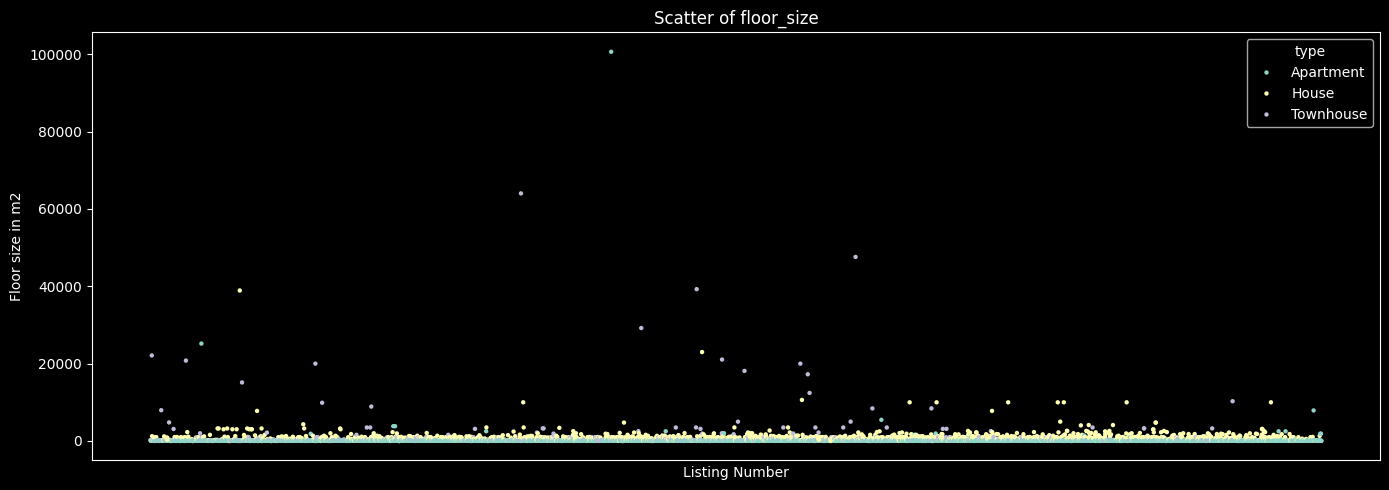

In [20]:
plt.figure(figsize=(14,5))
sns.scatterplot(
    data=res_df,
    x="listing_number",
    y="floor_size",
    hue="type",
    s=10,          # point size similar to 0.5 in ggplot
    linewidth=0
)

plt.xticks([], [])   # hide x-labels (too many IDs)
plt.xlabel("Listing Number")
plt.ylabel("Floor size in m2")
plt.title("Scatter of floor_size")
plt.tight_layout()
plt.show()

In [21]:
res_df.isnull().sum()

listing_number    0
price             0
location          0
bedrooms          0
bathrooms         0
parking           0
floor_size        0
type              0
dtype: int64

## Category Type- One Hot Encoding

In [22]:
res_df_encoded = pd.get_dummies(res_df, columns=['type'], drop_first=True)

## Split the data

In [23]:
X = res_df_encoded.drop(columns=['price',"listing_number"])
y = res_df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# Create encoder
loc_encoder = TargetEncoder(cols=['location'])

# Fit encoder ONLY on training set
X_train['location_enc'] = loc_encoder.fit_transform(X_train['location'], y_train)

# Transform both sets
X_train['location_enc'] = loc_encoder.transform(X_train['location'])
X_test['location_enc']  = loc_encoder.transform(X_test['location'])

# Drop original
X_train = X_train.drop(columns=['location'])
X_test  = X_test.drop(columns=['location'])

In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)

    mae  = mean_absolute_error(y_test, preds)
    rmse = root_mean_squared_error(y_test, preds)
    r2   = r2_score(y_test, preds)

    print(f"---- {name} ----")
    print(f"MAE:    {mae}\nRMSE:    {rmse}\nR2:    {r2}")

    return {
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


In [27]:
results = []

In [28]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
results.append(
    evaluate_model("Linear Regression", lr,  X_test_scaled, y_test)
)

---- Linear Regression ----
MAE:    5044.08370923228
RMSE:    8227.448726604518
R2:    0.6085123711569961


In [29]:
# 2. Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [5, 10, 20, None],
    'min_samples_leaf': [1, 2, 3],
    'min_samples_split': [2, 3, 4]
}

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_grid = GridSearchCV(
    rf,
    rf_param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
)


rf_grid.fit(X_train, y_train)



,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 3, ...], ...}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [30]:

print("Best Random Forest Parameters:", rf_grid.best_params_)
best_rf = rf_grid.best_estimator_

Best Random Forest Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [31]:
results.append(evaluate_model("Random Forest",best_rf,X_test,y_test))

---- Random Forest ----
MAE:    2789.447196708511
RMSE:    5383.113877784542
R2:    0.8324074116704223


In [32]:
# 3. XGBoost
xgb_param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=42,
    tree_method='hist',
    n_jobs=-1
)

xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    verbose=1,
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)



Fitting 3 folds for each of 108 candidates, totalling 324 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [200, 400, ...], ...}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [33]:
print("Best XGBoost Parameters:", xgb_grid.best_params_)
best_xgb = xgb_grid.best_estimator_

Best XGBoost Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 600, 'subsample': 0.8}


In [34]:
results.append(evaluate_model("XGBoost Regressor",best_xgb,X_test,y_test))

---- XGBoost Regressor ----
MAE:    2672.066683820186
RMSE:    5474.059341861344
R2:    0.8266967624524357


In [35]:
X_train.dtypes

bedrooms          float64
bathrooms         float64
parking           float64
floor_size        float64
type_House           bool
type_Townhouse       bool
location_enc      float64
dtype: object

In [36]:
from sklearn.model_selection import RandomizedSearchCV
# 4. LightGBM


lgb_param_grid = {
    'num_leaves': [31, 50, 80],
    'max_depth': [5, 10, -1],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 400],
    'min_child_samples': [5, 10, 20]
}


lgb = LGBMRegressor(
    objective='regression',
    random_state=42,
    n_jobs=4
)

lgb_random = RandomizedSearchCV(
    estimator=lgb,
    param_distributions=lgb_param_grid,
    n_iter=20,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=4,
    random_state=42
)

lgb_random.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.059607 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 475
[LightGBM] [Info] Number of data points in the train set: 2794, number of used features: 7
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.089729 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 472
[LightGBM] [Info] Start training from score 14291.943092
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.060600 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 475
[LightGBM] [Info] Number of data points in the train set: 2794, number of used features: 7
[LightGBM] [Info] Number of data points in the train set: 2795, number of used features: 7
[LightGBM] [Info] Start training from score 14291.943092
[LightGBM] [Info] Start trai

,estimator,LGBMRegressor...ndom_state=42)
,param_distributions,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [5, 10, ...], 'min_child_samples': [5, 10, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,20
,scoring,'neg_mean_absolute_error'
,n_jobs,4
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [37]:
print("Best LightGBM Parameters:", lgb_random.best_params_)
best_lgb = lgb_random.best_estimator_

Best LightGBM Parameters: {'num_leaves': 80, 'n_estimators': 400, 'min_child_samples': 5, 'max_depth': 5, 'learning_rate': 0.1}


In [38]:
results.append(evaluate_model("LightGBM", best_lgb,X_test,y_test))

---- LightGBM ----
MAE:    2787.2104559643158
RMSE:    5422.362195331911
R2:    0.829954665397393


In [39]:
results

[{'model': 'Linear Regression',
  'MAE': 5044.08370923228,
  'RMSE': 8227.448726604518,
  'R2': 0.6085123711569961},
 {'model': 'Random Forest',
  'MAE': 2789.447196708511,
  'RMSE': 5383.113877784542,
  'R2': 0.8324074116704223},
 {'model': 'XGBoost Regressor',
  'MAE': 2672.066683820186,
  'RMSE': 5474.059341861344,
  'R2': 0.8266967624524357},
 {'model': 'LightGBM',
  'MAE': 2787.2104559643158,
  'RMSE': 5422.362195331911,
  'R2': 0.829954665397393}]

In [40]:
results_df = pd.DataFrame(results)

In [41]:
results_df

,model,MAE,RMSE,R2
0,Linear Regression,5044.083709,8227.448727,0.608512
1,Random Forest,2789.447197,5383.113878,0.832407
2,XGBoost Regressor,2672.066684,5474.059342,0.826697
3,LightGBM,2787.210456,5422.362195,0.829955


In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

import joblib

In [66]:
num_features = ["bedrooms", "bathrooms", "parking", "floor_size"]
cat_onehot = ["type"]        
cat_target = ["location"]

preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"), cat_onehot),
        ("target", TargetEncoder(), cat_target),
        ("num", "passthrough", num_features)
    ]
)



In [67]:
best_rfr = RandomForestRegressor(
    max_depth=None,
    max_features='log2',
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", best_rfr)
])


In [68]:
X = res_df.drop(columns=["price", "listing_number",])
y = res_df["price"]

In [69]:
X

,location,bedrooms,bathrooms,parking,floor_size,type
2,Hatfield,8.0,8.0,8.0,212.00,Apartment
4,Olympus AH,3.0,2.0,2.0,202.00,Townhouse
26,Rietvalleirand,2.0,2.0,2.0,90.00,Apartment
30,Murrayfield,1.0,1.0,1.0,36.00,Apartment
40,Danville,3.0,2.0,1.0,73.00,House
...,...,...,...,...,...,...
7537,Roodeplaat,2.0,1.0,1.0,1867.67,Apartment
7538,Silverton,2.0,1.0,2.0,80.50,Apartment
7539,Roodeplaat,2.0,2.0,2.0,1867.67,Apartment
7540,Silverton,2.0,2.0,2.0,80.50,Apartment


In [70]:
model_pipeline.fit(X, y)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot', ...), ('target', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [72]:
joblib.dump(model_pipeline, "../models/rental_price_model.pkl")

['../models/rental_price_model.pkl']